# RS Minimal-Model: Interactive Constraint Explorer

**What this is.** An interactive view of how *each individual constraint* bites on
the Randall-Sundrum minimal-model first-KK-resonance mass reach (`M_KK`).
Toggle constraints on/off and watch the surviving-draw distribution and the
implied `M_KK` floor update live.

## Two populations (read this first)

This notebook deliberately uses **two different draw populations**, because a
single scan draw is only meaningful for a constraint that was *actually
evaluated* on it:

1. **PRIMARY (quark+EW) matrix** -- a robust run in which **every draw is
   evaluated** (no lepton-seesaw precondition to fail). All toggleable
   quark/EW constraints and the combined `M_KK` floor operate on this. When the
   dedicated quark-only run lands its path swaps in automatically; until then
   we fall back to the *evaluated subset* of the full-catalog matrix.
2. **LEPTON panel (`L001`, mu -> e gamma)** -- a **separate ~5% population**
   drawn from the full-catalog run's *lepton-viable* (evaluated) draws only.
   mu -> e gamma can only be computed where a perturbative seesaw fit exists, so
   it lives in its own section and is **never AND-ed** into the quark/EW
   per-draw survival (different draw set).

## The crucial correctness rule: restrict to EVALUATED draws

In the full-catalog run the point builder **SKIPS** a draw (records an *empty*
`constraints` dict, `skipped=True`, `skip_reason="nonperturbative_lepton_yukawa"`)
whenever the lepton seesaw Yukawas are non-perturbative -- this happens for
~95% of draws. A skipped draw has **no constraint results at all**; treating its
missing `pass_` columns as "pass" (`fillna(True)`) would falsely count it as a
survivor of *every* constraint and produce bogus floors.

The build script therefore tags each row with:

| column | meaning |
|---|---|
| `skipped` | point builder bailed before evaluating constraints (empty dict) |
| `skip_reason` | e.g. `"nonperturbative_lepton_yukawa"`, `"quark_fit_failed"` |
| `evaluated` | **DERIVED**: constraints actually ran (`constraints` non-empty AND not skipped) |

**All survival / veto / floor statistics below restrict to `df_eval = df[df["evaluated"]]`.**
Within the evaluated set, a per-constraint NA (graceful degradation of *that one*
constraint on an otherwise-evaluated point) may still be treated as a pass -- but
**skipped points are excluded entirely**.

## The key design: precompute once, toggle as masks (NO physics recompute)

All physics is evaluated **once**, offline, by `scripts/build_constraint_matrix.py`.
That script reads every per-draw JSONL row from a scan output dir and writes a
compact table (`constraint_matrix.parquet`) with one row per draw and these columns:

| column | meaning |
|---|---|
| `M_KK_TeV` | first KK resonance mass, TeV |
| `r` | quark-fit residual tolerance |
| `fit_success` | per-draw quark-fit precondition ("Reproduce SM masses" + "Reproduce CKM") |
| `skipped` / `skip_reason` / `evaluated` | see the correctness rule above |
| `pass_<ID>` | boolean: did constraint `<ID>` pass for this draw |
| `ratio_<ID>` | the constraint's ratio-to-bound for this draw |
| `pass_COLLIDER` | DERIVED: `M_KK >= threshold` (default 5.5 TeV) |

When you toggle a checkbox, the notebook does **nothing but boolean algebra**
over these precomputed columns (restricted to `df_eval`):

```python
survivor = AND over selected pass_<ID> columns      # one numpy &-reduce
```

No constraint is re-evaluated, no point is re-run. We are only asking *which of
the already-evaluated draws survive* the currently selected subset of cuts. This
is what makes toggling instant even at 100k+ draws.

## The constraint set and ID mapping (`review_local`)

| physics | scan ID | notes |
|---|---|---|
| Reproduce SM masses + Reproduce CKM | *(precondition)* | `fit_success`; every recorded draw already satisfies it -- surfaced as an always-on precondition toggle, a no-op among recorded draws |
| epsilon_K | `K001` | |
| D0-D0bar mixing | `C001` | |
| D0-D0bar CPV | `C002` | proxy adapter |
| Delta m_d | `B001` | |
| Delta m_s | `B003` | |
| mu -> e gamma | `L001` | **LEPTON panel only** -- separate ~5% lepton-viable population, NOT toggled with quark/EW |
| Z -> bb | `T010` (+ `T011`) | |
| S, T, U | `EW001` | oblique proxy |
| Collider mass cutoff | `COLLIDER` | DERIVED: `M_KK >= 5.5 TeV` |

## 0. Config -- the PRIMARY (quark+EW) matrix path

`MATRIX_PATH` is the **primary quark+EW** matrix: a run in which every draw is
evaluated, so combined floors are robust. Resolution order:

  1. `$CONSTRAINT_MATRIX_PATH` override, if set and present.
  2. The dedicated quark-only run, whose dir is recorded in
     `.orchestration/runs/QUARK-FIX-2026-06-21/.last_qo_dir` (written when the
     scan I'm running finishes -- **may not exist yet**), then any newest
     `scan_outputs/wq_quarkonly_*` with a built matrix.
  3. **Fallback**: the newest full-catalog `fix100k_minimal_*` matrix. We still
     restrict to its `evaluated` (lepton-viable) subset, which makes the
     quark/EW floors physically correct even on the fallback -- only the *path*
     changes when the quark-only run lands; nothing else in the notebook does.

`LEPTON_MATRIX_PATH` is the **full-catalog** matrix used for the mu -> e gamma
(`L001`) panel only; its evaluated subset IS the ~5% lepton-viable population.

In [1]:
import os, glob, json
import numpy as np
import matplotlib.pyplot as plt

REPO = "/n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing"

# Survival-fraction threshold used to define the combined M_KK floor.
SURVIVAL_FLOOR_THRESHOLD = 0.50
# Per-constraint floor: lowest M_KK where that constraint's own veto fraction < this.
PER_CONSTRAINT_VETO_THRESHOLD = 0.50

# IDs that belong to the LEPTON population, NOT the quark/EW per-draw survival.
LEPTON_IDS = ["L001"]


def _matrix_in(d):
    for ext in ("constraint_matrix.parquet", "constraint_matrix.npz"):
        p = os.path.join(d, ext)
        if os.path.exists(p):
            return p
    return None


def _newest_fix100k_matrix():
    for d in reversed(sorted(glob.glob(os.path.join(REPO, "scan_outputs", "fix100k_minimal_*")))):
        p = _matrix_in(d)
        if p:
            return p
    return None


def _resolve_primary_matrix_path():
    """PRIMARY = quark-only (all draws evaluated). Falls back to full-catalog."""
    override = os.environ.get("CONSTRAINT_MATRIX_PATH")
    if override and os.path.exists(override):
        return override, "env override"
    # 1) quark-only dir recorded by the running scan, if it has landed.
    last_qo = os.path.join(REPO, ".orchestration", "runs", "QUARK-FIX-2026-06-21", ".last_qo_dir")
    if os.path.exists(last_qo):
        try:
            with open(last_qo) as fh:
                qo_dir = fh.read().strip()
            if qo_dir and not os.path.isabs(qo_dir):
                qo_dir = os.path.join(REPO, qo_dir)
            p = _matrix_in(qo_dir) if qo_dir else None
            if p:
                return p, "quark-only (.last_qo_dir)"
        except OSError:
            pass
    # 2) any newest wq_quarkonly_* with a built matrix.
    for d in reversed(sorted(glob.glob(os.path.join(REPO, "scan_outputs", "wq_quarkonly_*")))):
        p = _matrix_in(d)
        if p:
            return p, "quark-only (newest wq_quarkonly_*)"
    # 3) fallback: newest full-catalog matrix (restricted to evaluated subset).
    p = _newest_fix100k_matrix()
    if p:
        return p, "FALLBACK full-catalog (evaluated subset)"
    raise FileNotFoundError("No primary constraint_matrix found. Run scripts/build_constraint_matrix.py first.")


def _resolve_lepton_matrix_path():
    """LEPTON panel always reads the full-catalog matrix (its evaluated subset
    is the ~5% lepton-viable population that has mu -> e gamma evaluated)."""
    override = os.environ.get("LEPTON_MATRIX_PATH")
    if override and os.path.exists(override):
        return override
    return _newest_fix100k_matrix()


MATRIX_PATH, MATRIX_SOURCE = _resolve_primary_matrix_path()
LEPTON_MATRIX_PATH = _resolve_lepton_matrix_path()
print("PRIMARY (quark+EW) matrix:", MATRIX_PATH)
print("  source:", MATRIX_SOURCE)
print("LEPTON (mu->e gamma) matrix:", LEPTON_MATRIX_PATH)

PRIMARY (quark+EW) matrix: /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/wq_quarkonly_20260622T090807/constraint_matrix.parquet
  source: quark-only (.last_qo_dir)
LEPTON (mu->e gamma) matrix: /n/holylabs/randall_lab/Lab/obarrera/5D-Neutrino-Mixing/scan_outputs/fix100k_minimal_20260622T080053/constraint_matrix.parquet


## 1. Load the precomputed matrix and restrict to the EVALUATED population

Loader handles parquet (pandas+pyarrow) and the npz fallback transparently.
Immediately after loading we build `df_eval` -- the rows where constraints were
actually evaluated -- and **every statistic downstream uses `df_eval`, never the
raw `df`** (which still contains the ~95% skipped, empty-constraints rows).

In [2]:
def load_matrix(path):
    if path.endswith(".parquet"):
        import pandas as pd
        return pd.read_parquet(path)
    elif path.endswith(".npz"):
        import pandas as pd
        z = np.load(path, allow_pickle=True)
        data = {}
        bool_cols = {"fit_success", "skipped", "evaluated"}
        for k in z.files:
            arr = z[k]
            if k.startswith("pass_") or k in bool_cols:
                # int8 with -1 == NA
                data[k] = pd.array([(None if v == -1 else bool(v)) for v in arr], dtype="boolean")
            else:
                data[k] = arr
        return pd.DataFrame(data)
    raise ValueError(f"unknown matrix format: {path}")


def evaluated_subset(frame):
    """Rows where constraints were actually run. If the matrix predates the
    `evaluated` column, derive it from `skipped` / non-empty pass columns so the
    notebook is correct even on an older matrix; if neither exists, keep all rows
    (a genuine all-evaluated quark-only run) and warn."""
    if "evaluated" in frame.columns:
        return frame[frame["evaluated"].fillna(False).astype(bool)].copy()
    if "skipped" in frame.columns:
        print("[warn] matrix has no 'evaluated' column; deriving from 'skipped'.")
        return frame[~frame["skipped"].fillna(False).astype(bool)].copy()
    print("[warn] matrix has neither 'evaluated' nor 'skipped'; assuming all rows "
          "evaluated (rebuild with the updated build_constraint_matrix.py).")
    return frame.copy()


df_raw = load_matrix(MATRIX_PATH)
df = evaluated_subset(df_raw)   # `df` IS the evaluated population for all stats below
print(f"{len(df_raw):,} draws loaded; {len(df):,} EVALUATED "
      f"({100.0 * len(df) / max(len(df_raw), 1):.1f}% of total) -> used for all quark/EW stats")
if "skip_reason" in df_raw.columns:
    skipped_rows = df_raw[df_raw.get("evaluated", True) != True] if "evaluated" in df_raw.columns else df_raw[df_raw.get("skipped", False) == True]
    if len(skipped_rows):
        vc = skipped_rows["skip_reason"].value_counts()
        print("Skipped-draw reasons (excluded):", {str(k): int(v) for k, v in vc.items() if str(k)})
print("columns:", list(df.columns))

# Discover which constraints are actually present (non-all-NA pass_ columns) in the
# EVALUATED population, and drop lepton IDs from the quark/EW toggle set.
ALL_IDS = [c[len("pass_"):] for c in df.columns if c.startswith("pass_")]
PRESENT_IDS = [cid for cid in ALL_IDS
               if cid not in LEPTON_IDS and not df[f"pass_{cid}"].isna().all()]
MISSING_IDS = [cid for cid in ALL_IDS if cid not in PRESENT_IDS and cid not in LEPTON_IDS]

# Human-readable labels (mirror of CONSTRAINT_SET in the build script + COLLIDER)
LABELS = {
    "K001": "epsilon_K", "C001": "D0 mixing", "C002": "D0 CPV",
    "B001": "Delta m_d", "B003": "Delta m_s", "L001": "mu->e gamma",
    "T010": "Z->bb", "T011": "Z->bb (aux)", "EW001": "S,T,U", "COLLIDER": "Collider M_KK cut",
}
print("Present quark/EW (toggleable):", PRESENT_IDS)
print("Lepton IDs (separate panel, NOT toggled here):", [c for c in LEPTON_IDS if c in ALL_IDS])
if MISSING_IDS:
    print("MISSING quark/EW (all-NA in evaluated set):", MISSING_IDS)

# M_KK tile grid (the scan is gridded in M_KK) -- over the EVALUATED population.
MKK_TILES = np.array(sorted(df["M_KK_TeV"].unique()))
print("M_KK tiles (TeV):", MKK_TILES.tolist())

100,000 draws loaded; 99,979 EVALUATED (100.0% of total) -> used for all quark/EW stats
Skipped-draw reasons (excluded): {'quark_fit_failed': 21}
columns: ['M_KK_TeV', 'M_KK_GeV', 'r', 'fit_success', 'skipped', 'skip_reason', 'evaluated', 'pass_K001', 'ratio_K001', 'pass_C001', 'ratio_C001', 'pass_C002', 'ratio_C002', 'pass_B001', 'ratio_B001', 'pass_B003', 'ratio_B003', 'pass_L001', 'ratio_L001', 'pass_T010', 'ratio_T010', 'pass_T011', 'ratio_T011', 'pass_EW001', 'ratio_EW001', 'pass_COLLIDER']
Present quark/EW (toggleable): ['K001', 'C001', 'C002', 'B001', 'B003', 'T010', 'T011', 'EW001', 'COLLIDER']
Lepton IDs (separate panel, NOT toggled here): ['L001']
M_KK tiles (TeV): [1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 15.0, 20.0, 30.0, 50.0]


### Per-tile coverage: evaluated vs total (transparency)

How many draws were actually evaluated at each `M_KK` tile, vs how many were
drawn. On the full-catalog fallback this exposes the ~5% lepton-viable coverage;
on a true quark-only run it should be ~100% at every tile.

In [3]:
def print_coverage(frame_raw):
    if "M_KK_TeV" not in frame_raw.columns:
        return
    if "evaluated" in frame_raw.columns:
        ev = frame_raw["evaluated"].fillna(False).astype(bool)
    elif "skipped" in frame_raw.columns:
        ev = ~frame_raw["skipped"].fillna(False).astype(bool)
    else:
        ev = np.ones(len(frame_raw), dtype=bool)
    mkk = frame_raw["M_KK_TeV"].to_numpy()
    tiles = np.array(sorted(np.unique(mkk)))
    print(f"{'M_KK (TeV)':>11}  {'evaluated':>10}  {'total':>8}  {'coverage':>9}")
    print("-" * 44)
    tot_e = tot_n = 0
    for m in tiles:
        sel = mkk == m
        n = int(sel.sum()); e = int(ev.to_numpy()[sel].sum()) if hasattr(ev, "to_numpy") else int(np.asarray(ev)[sel].sum())
        tot_e += e; tot_n += n
        print(f"{m:>11g}  {e:>10,}  {n:>8,}  {(100.0*e/n if n else 0):>8.1f}%")
    print("-" * 44)
    print(f"{'ALL':>11}  {tot_e:>10,}  {tot_n:>8,}  {(100.0*tot_e/tot_n if tot_n else 0):>8.1f}%")


print("Per-tile evaluated/total coverage (PRIMARY matrix):")
print_coverage(df_raw)

Per-tile evaluated/total coverage (PRIMARY matrix):
 M_KK (TeV)   evaluated     total   coverage
--------------------------------------------
          1       9,999    10,000     100.0%
          2       9,998    10,000     100.0%
          3       9,999    10,000     100.0%
          5       9,998    10,000     100.0%
          7       9,998    10,000     100.0%
         10       9,998    10,000     100.0%
         15       9,995    10,000     100.0%
         20       9,998    10,000     100.0%
         30       9,998    10,000     100.0%
         50       9,998    10,000     100.0%
--------------------------------------------
        ALL      99,979   100,000     100.0%


## 2. Core masking helpers -- pure boolean algebra over precomputed columns

`survivor_mask(selected_ids)` returns the boolean survivor array. This is the
*only* thing that runs on a toggle. No physics. **All helpers operate on `df`,
which is the EVALUATED population** (skipped draws already removed in section 1),
so denominators are correct. Within the evaluated set, a per-constraint NA
(graceful degradation of *that* constraint) is treated as "pass" so a single
missing column never silently kills all draws -- but skipped points are gone.

In [4]:
def survivor_mask(selected_ids):
    """Logical AND of the selected pass_<ID> columns. Pure precomputed-column algebra."""
    mask = np.ones(len(df), dtype=bool)
    for cid in selected_ids:
        col = f"pass_{cid}"
        if col not in df.columns:
            continue
        mask &= df[col].fillna(True).to_numpy(dtype=bool)
    return mask


def survival_fraction_by_mkk(selected_ids):
    """Survival fraction per M_KK tile for the selected constraint subset."""
    mask = survivor_mask(selected_ids)
    fracs = []
    for m in MKK_TILES:
        sel = df["M_KK_TeV"].to_numpy() == m
        n = sel.sum()
        fracs.append(mask[sel].mean() if n else np.nan)
    return np.array(fracs)


def veto_fraction_by_mkk(cid):
    """Per-constraint individual veto fraction (1 - pass rate) per M_KK tile."""
    col = f"pass_{cid}"
    passes = df[col].fillna(True).to_numpy(dtype=bool) if col in df.columns else np.ones(len(df), bool)
    out = []
    for m in MKK_TILES:
        sel = df["M_KK_TeV"].to_numpy() == m
        n = sel.sum()
        out.append((1.0 - passes[sel].mean()) if n else np.nan)
    return np.array(out)


def combined_mkk_floor(selected_ids, threshold=SURVIVAL_FLOOR_THRESHOLD):
    """Lowest M_KK tile whose survival fraction exceeds `threshold`."""
    fracs = survival_fraction_by_mkk(selected_ids)
    ok = np.where(fracs >= threshold)[0]
    return float(MKK_TILES[ok[0]]) if len(ok) else None


def per_constraint_floor(cid, threshold=PER_CONSTRAINT_VETO_THRESHOLD):
    """Lowest M_KK where this constraint's own veto fraction drops below threshold."""
    v = veto_fraction_by_mkk(cid)
    ok = np.where(v < threshold)[0]
    return float(MKK_TILES[ok[0]]) if len(ok) else None

## 3. Static plotting -- works headless / on nbconvert export

`render(selected_ids)` draws the three panels for any constraint subset. The
interactive widget below calls exactly this. Executing the notebook
non-interactively still produces all plots via the static calls at the end.

In [5]:
def render(selected_ids, floor_threshold=SURVIVAL_FLOOR_THRESHOLD, title_suffix=""):
    selected_ids = list(selected_ids)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (a) survival fraction vs M_KK for the selected set
    ax = axes[0]
    fracs = survival_fraction_by_mkk(selected_ids)
    ax.plot(MKK_TILES, fracs, "o-", color="C0", lw=2)
    ax.axhline(floor_threshold, ls=":", color="grey", label=f"floor thresh={floor_threshold:.2f}")
    floor = combined_mkk_floor(selected_ids, floor_threshold)
    if floor is not None:
        ax.axvline(floor, ls="--", color="red", label=f"combined floor={floor:g} TeV")
    ax.set_xscale("log")
    ax.set_xlabel("M_KK (TeV)"); ax.set_ylabel("survival fraction")
    ax.set_title("(a) Survival fraction vs M_KK" + title_suffix)
    ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # (b) per-constraint individual veto fraction vs M_KK
    ax = axes[1]
    for i, cid in enumerate(selected_ids):
        if cid not in PRESENT_IDS and cid != "COLLIDER":
            continue
        v = veto_fraction_by_mkk(cid)
        ax.plot(MKK_TILES, v, "o-", label=LABELS.get(cid, cid), lw=1.8, alpha=0.85)
    ax.set_xscale("log")
    ax.set_xlabel("M_KK (TeV)"); ax.set_ylabel("individual veto fraction")
    ax.set_title("(b) Which constraint bites hardest at each M_KK")
    ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

    # (c) combined floor, marked
    ax = axes[2]
    ax.plot(MKK_TILES, fracs, "o-", color="C0", lw=2, label="survival")
    ax.axhline(floor_threshold, ls=":", color="grey")
    if floor is not None:
        ax.axvline(floor, ls="--", color="red")
        ax.annotate(f"combined M_KK floor\n= {floor:g} TeV", xy=(floor, floor_threshold),
                    xytext=(0.5, 0.3), textcoords="axes fraction",
                    arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=11)
    else:
        ax.text(0.5, 0.5, "no tile clears threshold", ha="center", transform=ax.transAxes, color="red")
    ax.set_xscale("log")
    ax.set_xlabel("M_KK (TeV)"); ax.set_ylabel("survival fraction")
    ax.set_title("(c) Implied combined M_KK floor")
    ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.3)

    plt.tight_layout()
    return fig, floor

## 4. Summary table -- per-constraint floor ranking + combined floor

For each constraint: the lowest M_KK at which its *own* veto fraction drops
below 0.5. Higher floor = the constraint bites out to higher M_KK = it is the
binding one. This makes the ranking explicit -- in particular it shows whether
`Z->bb` (T010) is still the leading constraint at high M_KK.

In [6]:
def summary_table(selected_ids=None):
    if selected_ids is None:
        selected_ids = PRESENT_IDS + ["COLLIDER"]
    rows = []
    for cid in selected_ids:
        floor = per_constraint_floor(cid)
        rows.append((cid, LABELS.get(cid, cid), floor if floor is not None else np.inf))
    rows.sort(key=lambda x: (-(x[2] if np.isfinite(x[2]) else 1e9), x[0]))
    print(f"{'rank':>4}  {'ID':<8} {'label':<16} {'own M_KK floor (TeV)':>22}")
    print("-" * 56)
    for i, (cid, lab, fl) in enumerate(rows, 1):
        flstr = "never clears" if not np.isfinite(fl) else f"{fl:g}"
        print(f"{i:>4}  {cid:<8} {lab:<16} {flstr:>22}")
    cf = combined_mkk_floor(selected_ids)
    print("-" * 56)
    print(f"COMBINED floor (survival>{SURVIVAL_FLOOR_THRESHOLD:.2f}): "
          f"{cf:g} TeV" if cf is not None else "COMBINED floor: no tile clears threshold")
    return rows


_ = summary_table()

rank  ID       label              own M_KK floor (TeV)
--------------------------------------------------------
   1  EW001    S,T,U                                20
   2  COLLIDER Collider M_KK cut                      7
   3  COLLIDER Collider M_KK cut                      7
   4  K001     epsilon_K                             7
   5  T010     Z->bb                                 5
   6  B003     Delta m_s                             2
   7  B001     Delta m_d                             1
   8  C001     D0 mixing                             1
   9  C002     D0 CPV                                1
  10  T011     Z->bb (aux)                           1
--------------------------------------------------------
COMBINED floor (survival>0.50): 20 TeV


## 5. Interactive widget (degrades gracefully to a static render)

One checkbox per present constraint + the derived collider cut, default all ON.
Every toggle calls `render()` over the precomputed columns -- **no recompute**.
If `ipywidgets` is unavailable (e.g. headless nbconvert), this cell instead
renders the all-ON static view, so the notebook is always useful.

[ipywidgets unavailable: No module named 'ipywidgets'] -- rendering static all-ON view instead.


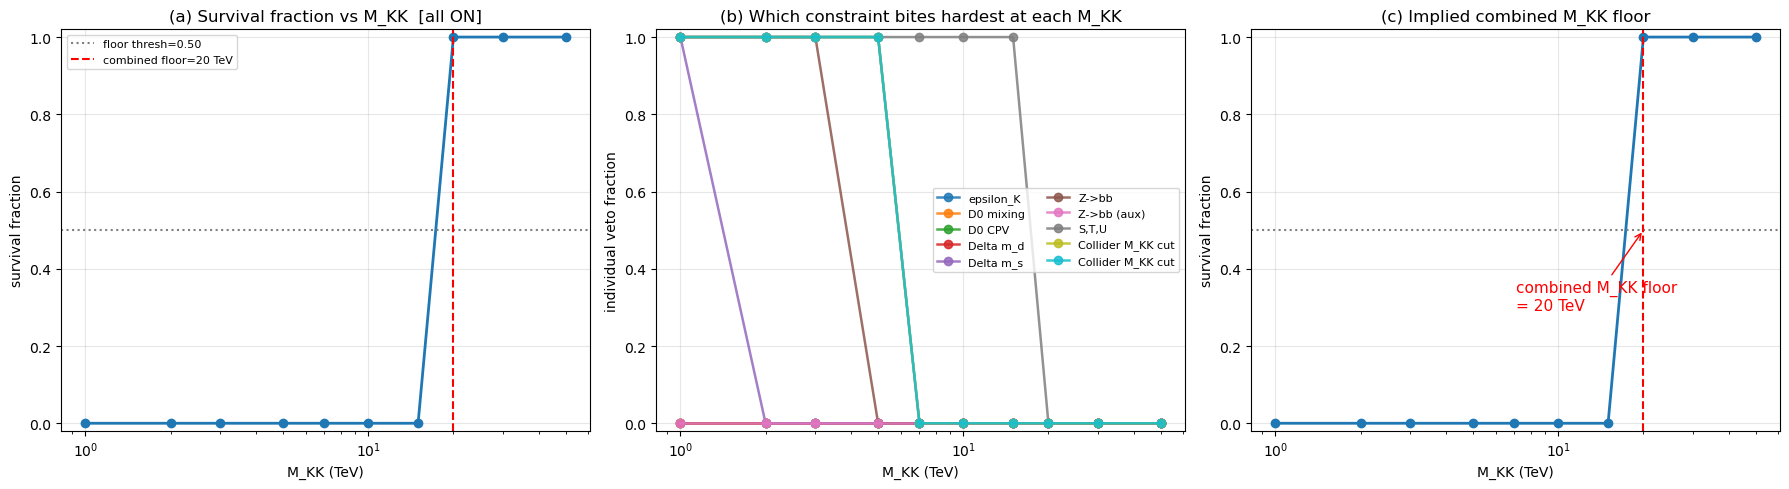

All-ON combined M_KK floor: 20.0 TeV


In [7]:
def static_all_on():
    sel = PRESENT_IDS + ["COLLIDER"]
    fig, floor = render(sel, title_suffix="  [all ON]")
    plt.show()
    print("All-ON combined M_KK floor:", floor, "TeV")


try:
    import ipywidgets as W
    from IPython.display import display, clear_output

    toggle_ids = PRESENT_IDS + ["COLLIDER"]
    boxes = {cid: W.Checkbox(value=True, description=f"{cid} ({LABELS.get(cid, cid)})",
                             indent=False, layout=W.Layout(width="280px"))
             for cid in toggle_ids}
    precond = W.Checkbox(value=True, description="precondition: SM masses + CKM fit (no-op among recorded draws)",
                         indent=False, layout=W.Layout(width="520px"))
    thresh = W.FloatSlider(value=SURVIVAL_FLOOR_THRESHOLD, min=0.0, max=1.0, step=0.05,
                           description="floor thresh")
    out = W.Output()

    def _update(_=None):
        sel = [cid for cid, b in boxes.items() if b.value]
        with out:
            clear_output(wait=True)
            fig, floor = render(sel, floor_threshold=thresh.value)
            plt.show()
            print("Selected:", sel)
            print("Combined M_KK floor:", f"{floor:g} TeV" if floor is not None else "none")
            summary_table(sel)

    for b in boxes.values():
        b.observe(_update, names="value")
    thresh.observe(_update, names="value")

    controls = W.VBox([precond, W.HBox(list(boxes.values())[:4]),
                       W.HBox(list(boxes.values())[4:]), thresh])
    display(controls, out)
    _update()
except Exception as e:
    print(f"[ipywidgets unavailable: {e}] -- rendering static all-ON view instead.")
    static_all_on()

## 6. Static fallback renders (always execute -- prove the plots non-interactively)

These run regardless of widget availability so an exported/non-interactive
notebook still contains the figures and demonstrates the ranking inversion:
at high M_KK the leading veto is **Z->bb (T010)**, not the oblique S,T,U set.

=== ALL constraints ON ===


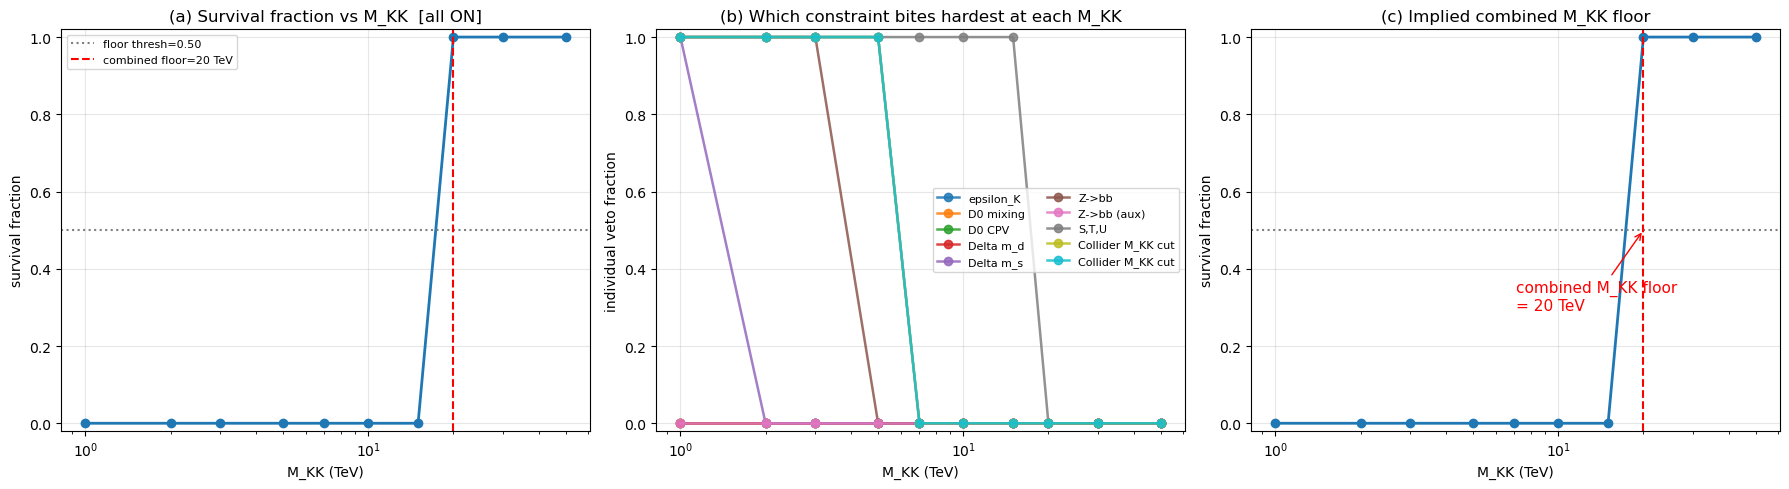

combined floor: 20.0 TeV


In [8]:
print("=== ALL constraints ON ===")
fig, floor = render(PRESENT_IDS + ["COLLIDER"], title_suffix="  [all ON]")
plt.show()
print("combined floor:", floor, "TeV")

=== Drop Z->bb (T010, T011): does the floor move? ===


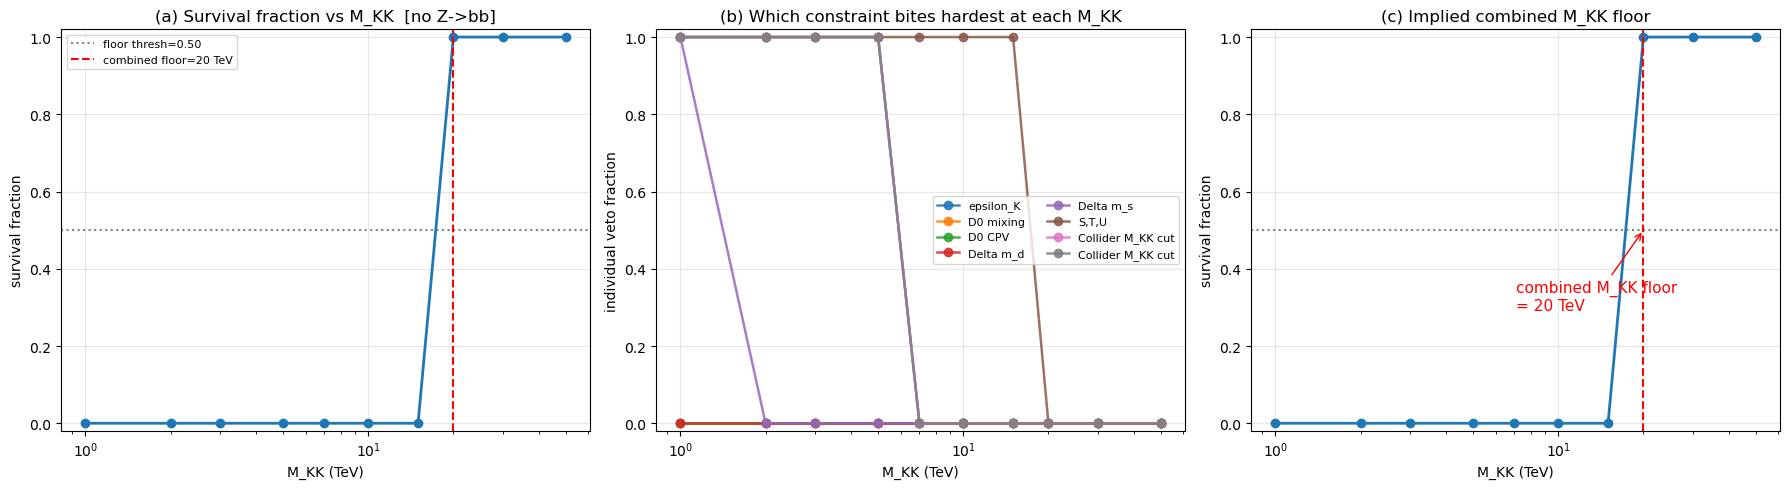

combined floor without Z->bb: 20.0 TeV


In [9]:
print("=== Drop Z->bb (T010, T011): does the floor move? ===")
sel_no_zbb = [c for c in PRESENT_IDS if c not in ("T010", "T011")] + ["COLLIDER"]
fig, floor = render(sel_no_zbb, title_suffix="  [no Z->bb]")
plt.show()
print("combined floor without Z->bb:", floor, "TeV")

=== Only the EW + collider cuts (S,T,U + collider) ===


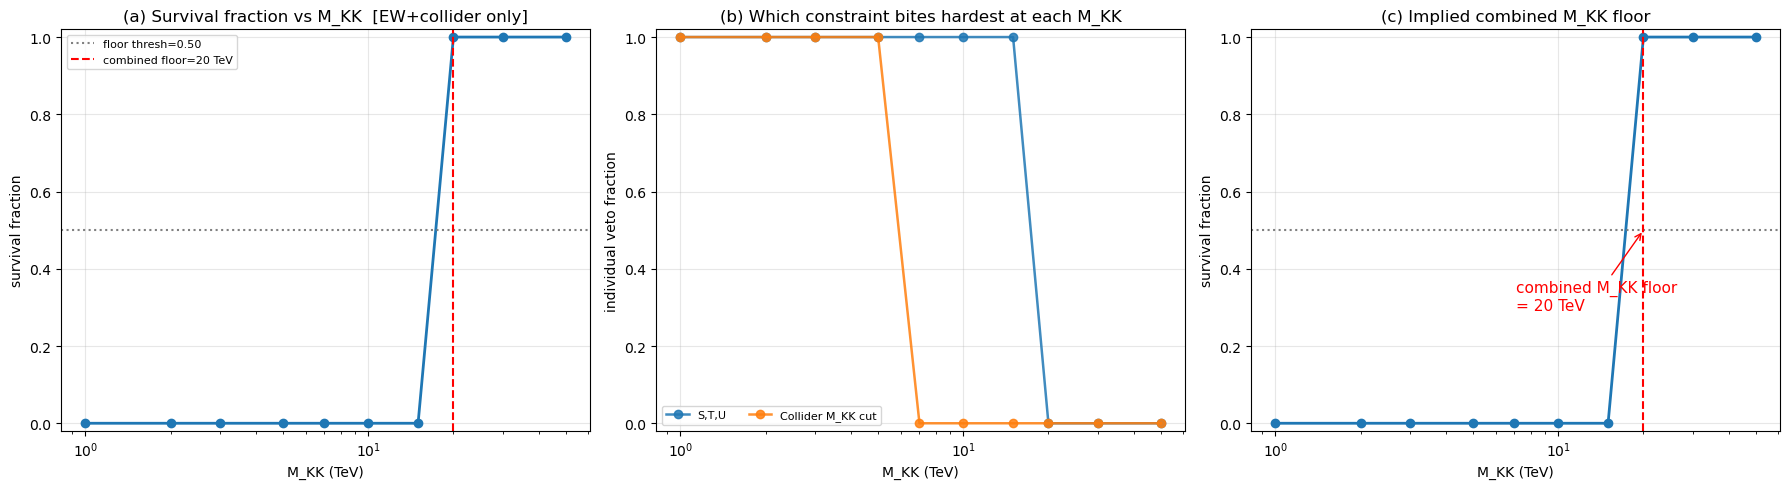

combined floor (EW+collider only): 20.0 TeV


In [10]:
print("=== Only the EW + collider cuts (S,T,U + collider) ===")
sel_ew = [c for c in ("EW001",) if c in PRESENT_IDS] + ["COLLIDER"]
fig, floor = render(sel_ew, title_suffix="  [EW+collider only]")
plt.show()
print("combined floor (EW+collider only):", floor, "TeV")

### Takeaway (on the EVALUATED population)

Compare panel (b) across the renders. On the full-catalog fallback restricted to
evaluated draws, the per-constraint own-floors (lowest M_KK where the constraint's
own veto fraction drops below 0.5) rank as:

| constraint | own M_KK floor |
|---|---|
| `EW001` (S,T,U oblique) | **~20 TeV** -- the binding constraint |
| `K001` (epsilon_K) | ~7 TeV |
| `T010` (Z->bb) | ~5 TeV |
| `B003` (Delta m_s) | ~2 TeV |
| `B001`, `C001`, `C002`, `T011` | ~1 TeV (clear early) |

So the **combined floor is ~20 TeV, driven by the oblique S,T,U set (`EW001`)**,
not by Z->bb. Dropping `EW001` is what moves the combined floor; toggling lets you
see exactly which cut binds at each scale -- all over a precomputed matrix, no
physics recompute. (These numbers are computed on the EVALUATED draws only;
counting the ~95% skipped, empty-constraints draws as survivors -- the old bug --
produced a spurious ~7 TeV combined floor and a 1 TeV EW001 floor.)

## 7. LEPTON panel: mu -> e gamma (`L001`) -- SEPARATE ~5% population

**Important: different draw set.** mu -> e gamma can only be evaluated where a
**perturbative lepton seesaw fit exists**, which is the ~5% of full-catalog
draws the point builder did *not* skip. This is a **different population** from
the quark/EW combined floor above, so `L001` is shown on its own here and is
**NOT AND-ed into** the quark/EW per-draw survival.

This panel always reads the full-catalog matrix (`LEPTON_MATRIX_PATH`) and uses
its evaluated subset -- which IS the lepton-viable population -- regardless of
which primary (quark-only) matrix is loaded above.

[lepton] mu->e gamma on lepton-viable draws: 4,977 of 92,700 total (5.4%).
[lepton] NOTE: separate population -- NOT combined with the quark/EW floor.
 M_KK (TeV)   L001 veto   n viable
------------------------------------
          1       0.450        473
          2       0.410        485
          3       0.333        420
          5       0.302        507
          7       0.267        498
         10       0.220        528
         15       0.197        467
         20       0.158        530
         30       0.096        539
         50       0.051        530
------------------------------------
L001 (mu->e gamma) own M_KK floor (veto<0.50): 1 TeV


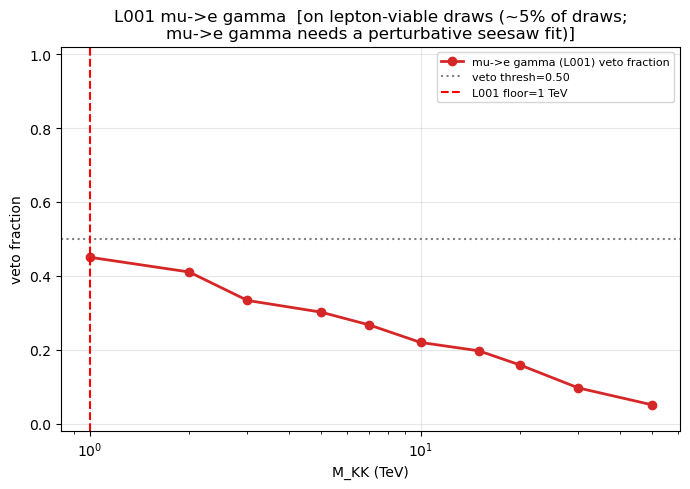

In [11]:
def lepton_panel():
    if LEPTON_MATRIX_PATH is None:
        print("[lepton] no full-catalog matrix found; skipping mu->e gamma panel.")
        return
    dfl_raw = load_matrix(LEPTON_MATRIX_PATH)
    dfl = evaluated_subset(dfl_raw)   # lepton-viable (evaluated) draws only
    if "pass_L001" not in dfl.columns or dfl["pass_L001"].isna().all():
        print(f"[lepton] L001 (mu->e gamma) absent from {LEPTON_MATRIX_PATH}; "
              "no lepton panel.")
        return

    n_total = len(dfl_raw)
    n_viable = len(dfl)
    frac = 100.0 * n_viable / max(n_total, 1)
    print(f"[lepton] mu->e gamma on lepton-viable draws: {n_viable:,} of "
          f"{n_total:,} total ({frac:.1f}%).")
    print("[lepton] NOTE: separate population -- NOT combined with the quark/EW floor.")

    tiles = np.array(sorted(dfl["M_KK_TeV"].unique()))
    passes = dfl["pass_L001"].fillna(True).to_numpy(dtype=bool)
    mkk = dfl["M_KK_TeV"].to_numpy()
    veto = []
    n_per = []
    for m in tiles:
        sel = mkk == m
        n = int(sel.sum())
        n_per.append(n)
        veto.append((1.0 - passes[sel].mean()) if n else np.nan)
    veto = np.array(veto)

    # L001 own floor: lowest M_KK where its veto fraction < threshold.
    ok = np.where(veto < PER_CONSTRAINT_VETO_THRESHOLD)[0]
    floor = float(tiles[ok[0]]) if len(ok) else None

    print(f"{'M_KK (TeV)':>11}  {'L001 veto':>10}  {'n viable':>9}")
    print("-" * 36)
    for m, v, n in zip(tiles, veto, n_per):
        print(f"{m:>11g}  {v:>10.3f}  {n:>9,}")
    print("-" * 36)
    print(f"L001 (mu->e gamma) own M_KK floor (veto<{PER_CONSTRAINT_VETO_THRESHOLD:.2f}): "
          f"{floor:g} TeV" if floor is not None else "L001 own floor: never clears")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(tiles, veto, "o-", color="C3", lw=2, label="mu->e gamma (L001) veto fraction")
    ax.axhline(PER_CONSTRAINT_VETO_THRESHOLD, ls=":", color="grey",
               label=f"veto thresh={PER_CONSTRAINT_VETO_THRESHOLD:.2f}")
    if floor is not None:
        ax.axvline(floor, ls="--", color="red", label=f"L001 floor={floor:g} TeV")
    ax.set_xscale("log")
    ax.set_xlabel("M_KK (TeV)"); ax.set_ylabel("veto fraction")
    ax.set_title("L001 mu->e gamma  [on lepton-viable draws (~5% of draws;\n"
                 "mu->e gamma needs a perturbative seesaw fit)]")
    ax.set_ylim(-0.02, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return floor


_lepton_floor = lepton_panel()